# Recommendation Systems - MovieLens 100K

This project combines Collaborative Filtering (1) and Content-Based Filtering (2), making it a hybrid model. 

1) Collaborative Filtering - It predicts what a user will like based on the patterns of other **similar users**.

2) Content-Based Filtering - It recommends items based on the **characteristics of the items themselves** and the user's profile.

In [40]:
import pandas as pd
import numpy as np


### Dataset Load 

In [41]:
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")
tags = pd.read_csv("tags.csv")
links = pd.read_csv("links.csv")

In [42]:
print("Ratings:")
print(ratings.head(), "\n")

print("Movies:")
print(movies.head(), "\n")

print("Tags:")
print(tags.head(), "\n")    

print("Links:")
print(links.head(), "\n")

Ratings:
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931 

Movies:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy   

Tags:
   userId  movieId              tag   timestamp
0       2    60756            funny  1445714994
1       2    60756  Highly quotable  1445714996
2     

- ratings -> user reviews
- movies -> titles and genres
- tags -> tags associated with movies

### Merge movies and links

In [43]:
# merge movies and links using movieID 
movies_links = pd.merge(movies, links, on='movieId', how='left')

# preview merge dataframe
movies_links.head()

,movieId,title,genres,imdbId,tmdbId
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,113497,8844.0
2,3,Grumpier Old Men (1995),Comedy|Romance,113228,15602.0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,114885,31357.0
4,5,Father of the Bride Part II (1995),Comedy,113041,11862.0


## Content-Based Filtering

Create a model that:
- transforms movie genres into numerical vectors,
- calculates similarity between movies,
- allows you to recommend movies similar to any other movie.

In [44]:
# replace '|' with space so TF-IDF can treat genres as separate tokens
movies_links['genres_clean'] = movies_links['genres'].str.replace('|', ' ')

TF‑IDF = Term Frequency – Inverse Document Frequency --> It's a classic technique for transforming text into vectors.


In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

# create TF-IDF matrix from cleaned genres
tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(movies_links['genres_clean'])

In [46]:
from sklearn.metrics.pairwise import cosine_similarity

# compute cosine similarity between all movies
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [47]:
# function to recommend similar movies based on cosine similarity 
def recommend_similar_movies(movie_title, movies_df, cb_similarity, top_n=10):
    # get index of the movie
    idx = movies_df[movies_df['title'] == movie_title].index[0]

    # get similarity scores for this movie
    sim_scores = list(enumerate(cb_similarity[idx]))

    # sort the movies by similarity scores (descending order)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # skip the first one (it's the movie itself)
    sim_scores = sim_scores[1:top_n+1]

    # return movie titles
    movie_indices = [i[0] for i in sim_scores]
    return movies_df.iloc[movie_indices][['movieId', 'title', 'genres']]

In [48]:
# test the function with a sample movie
recommend_similar_movies("Toy Story (1995)", movies_links, cosine_sim, top_n=10)

,movieId,title,genres
1706,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy
2355,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
2809,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3000,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3568,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy
6194,45074,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy
6486,53121,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy
6948,65577,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy
7760,91355,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy
8219,103755,Turbo (2013),Adventure|Animation|Children|Comedy|Fantasy


## Advanced Content-Based (TMDB + Embeddings)

Use the tmdbId to:
- Obtain actual movie descriptions via the TMDB API
- Convert these descriptions into semantic vectors (embeddings)
- Calculate similarity between movies based on the meaning of the text

In [49]:
from dotenv import load_dotenv
import os
import requests

# load environment variables from .env file
load_dotenv()

# read TMDB API key
tmdb_api_key = os.getenv("TMDB_API_KEY")

In [50]:
cache = {}

def get_tmdb_description_cached(tmdb_id, api_key):
    if tmdb_id in cache:
        return cache[tmdb_id]
    url = f"https://api.themoviedb.org/3/movie/{tmdb_id}?api_key={api_key}&language=en-US"
    response = requests.get(url, timeout=10)
    if response.status_code == 200:
        data = response.json()
        desc = data.get("overview", "")
        cache[tmdb_id] = desc
        return desc
    return ""


In [51]:
import os
from tqdm import tqdm
import time

# Prevent overwriting if file already exists
if os.path.exists("movies_with_descriptions.csv"):
    print("File already exists. Skipping description extraction.")
    movies_links = pd.read_csv("movies_with_descriptions.csv")  # load existing data
else:
    movies_links["description"] = ""  # create column only if file doesn't exist

    for idx, tmdb_id in tqdm(zip(movies_links.index, movies_links["tmdbId"]),
                             total=len(movies_links),
                             desc="Fetching TMDB descriptions"):
        if pd.notnull(tmdb_id):
            desc = get_tmdb_description_cached(tmdb_id, tmdb_api_key)
            movies_links.at[idx, "description"] = desc
            time.sleep(0.2)

    movies_links.to_csv("movies_with_descriptions.csv", index=False)
    print("Descriptions saved in movies_with_descriptions.csv")


File already exists. Skipping description extraction.


In [52]:
import shutil

# Create a backup copy
shutil.copy("movies_with_descriptions.csv", "movies_with_descriptions_backup.csv")
print("Backup created successfully.")


Backup created successfully.


### Merge movies + tags

In [53]:
movies_links_tags = pd.merge(movies_links, tags, on="movieId", how="left")

In [54]:
movies_links_tags['tags'] = movies_links_tags.groupby('movieId')['tag'].transform(
    lambda x: ' '.join(x.dropna().unique())
)
movies_links_tags = movies_links_tags.drop_duplicates(subset='movieId')


In [55]:
movies_links_tags['year'] = movies_links_tags['title'].str.extract(r'\((\d{4})\)', expand=False).fillna('')

In [56]:
movies_links_tags['combined_text'] = (
    movies_links_tags['description'].fillna('') + ' ' +
    movies_links_tags['genres'].fillna('') + ' ' +
    movies_links_tags['year'].astype(str) + ' ' +
    movies_links_tags['tags'].fillna('')
)


### Embedding 

In [57]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-mpnet-base-v2')

def safe_encode(text):
    if isinstance(text, str) and text.strip():
        return model.encode(text)
    else:
        
        return np.zeros(model.get_sentence_embedding_dimension())

movies_links_tags['embedding'] = movies_links_tags['combined_text'].apply(safe_encode)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5882.53it/s]


- Each row in the description column was converted into a numerical vector (embedding).

- These vectors represent the semantic meaning of the descriptions — that is, movies with similar descriptions will have embeddings close to each other.

In [58]:
# Save embeddings to a .pkl file
import pickle

with open("movie_embeddings.pkl", "wb") as f:
    pickle.dump(movies_links_tags['embedding'].tolist(), f)

print("Embeddings saved successfully to movie_embeddings.pkl")

Embeddings saved successfully to movie_embeddings.pkl


In [59]:
# now we can measure how similar the movies are based on these embeddings
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Compute similarity matrix
embeddings = np.vstack(movies_links_tags['embedding'].values)
cb_similarity = cosine_similarity(embeddings)

print(cb_similarity.shape)

(9742, 9742)


### Recommendation function

In [60]:
def recommend_movie(title, top_n=5):
    idx = movies_links_tags[movies_links_tags['title'] == title].index[0]
    sim_scores = list(enumerate(cb_similarity[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    recommendations = movies_links_tags.iloc[[i[0] for i in sim_scores]][['title', 'description']]
    return recommendations

In [61]:
# test
recommend_movie("Toy Story (1995)")

,title,description
3210,Toy Story 2 (1999),"Andy heads off to Cowboy Camp, leaving his toy..."
9050,Toy Story 3 (2010),"Woody, Buzz, and the rest of Andy's toys haven..."
274,"Goofy Movie, A (1995)",Goofy’s teenage son Max is desperate to impres...
8870,Mickey's Once Upon a Christmas (1999),"Mickey, Minnie, and their famous friends Goofy..."
10812,Tom and Jerry: A Nutcracker Tale (2007),Christmas is never so spirited as when Tom and...


### We need to refine the recommendation model

In [62]:
movies_links_tags['combined_text'] = (
    movies_links_tags['description'].fillna('') + ' ' +
    movies_links_tags['genres'].fillna('') + ' ' +
    movies_links_tags['year'].astype(str) + ' ' +
    movies_links_tags['tags'].fillna('') + ' ' +
    movies_links_tags['title'].fillna('')
)

In [63]:
movies_links_tags['embedding'] = movies_links_tags['combined_text'].apply(safe_encode)

In [ ]:
def recommend_movie(title, top_n=5):
   # search title in a more flexible way
    matches = movies_links_tags[movies_links_tags['title'].str.contains(title, case=False, na=False)]
    
    if matches.empty:
        print(f" Title '{title}' not found.")
        return pd.DataFrame(columns=['title', 'description'])

    if len(matches) > 1:
        print(f"Warning: {len(matches)} movies correspond to '{title}'. Using: {matches['title'].iloc[0]} ")
    
    idx = matches.index[0]
    sim_scores = list(enumerate(cb_similarity[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    
    recommendations = movies_links_tags.iloc[[i for i, _ in sim_scores]][['title', 'description']]
    return recommendations


In [65]:
recommend_movie('Matrix')


,title,description
2810,Spartacus (1960),"The rebellious Thracian Spartacus, born and ra..."
9562,Coriolanus (2011),"Caius Martius, aka Coriolanus, is an arrogant ..."
8032,"Last Legion, The (2007)","As the Roman empire crumbles, young Romulus Au..."
11632,War for the Planet of the Apes (2017),Caesar and his apes are forced into a deadly c...
7902,300 (2007),A story very loosely based the 480 B.C. Battle...


## Collaborative Filtering 

In [66]:
np.random.seed(42)

def multi_holdout_split(ratings_df, min_ratings=8, like_threshold=4, n_holdout=3):
    test_rows, train_frames = [], []
    for uid, group in ratings_df.groupby('userId'):
        liked = group[group['rating'] >= like_threshold]
        if len(group) < min_ratings or len(liked) < n_holdout:
            train_frames.append(group)
            continue
        held_out = liked.sample(n_holdout, random_state=42)
        test_rows.append(held_out)
        train_frames.append(group.drop(held_out.index))
    return pd.concat(train_frames).reset_index(drop=True), pd.concat(test_rows).reset_index(drop=True)

ratings_train, ratings_test = multi_holdout_split(ratings)

In [67]:
ratings_matrix = ratings_train.pivot_table(index='userId', columns='movieId', values='rating')

In [68]:
# normalize ratings
ratings_norm = ratings_matrix.sub(ratings_matrix.mean(axis=1), axis=0)

In [69]:
# calculate similarity 

from sklearn.metrics.pairwise import cosine_similarity
item_similarity_cf = cosine_similarity(ratings_norm.fillna(0).T)
item_similarity_cf = pd.DataFrame(item_similarity_cf, 
                                  index=ratings_norm.columns,
                                  columns=ratings_norm.columns)

In [70]:
# create a column with the CF index
movies_links_tags = movies_links_tags[movies_links_tags['movieId'].isin(item_similarity_cf.index)]
movies_links_tags = movies_links_tags.reset_index(drop=True)

In [71]:
embeddings = np.vstack(movies_links_tags['embedding'].values)
cb_similarity = cosine_similarity(embeddings)

In [72]:
id_to_index = {mid: idx for idx, mid in enumerate(movies_links_tags['movieId'])}

**Hybrid function:** score = 𝛼 ⋅ CB + (1−𝛼) ⋅ CF
- 𝛼 - weights

In [73]:
def hybrid_recommend(title, top_n=5, alpha=0.7):
    # find movie
    matches = movies_links_tags[movies_links_tags['title'].str.contains(title, case=False, na=False)]
    if matches.empty:
        print(f"Title '{title}' not found.")
        return None

    if len(matches) > 1:
        print(f"Warning: {len(matches)} movies correspond to '{title}'. Using: {matches['title'].iloc[0]} ")
    
    movie_idx = matches.index[0]
    movie_id = matches['movieId'].iloc[0]

    # CB scores
    cb_scores = cb_similarity[movie_idx]

    # CF scores
    cf_scores = item_similarity_cf.loc[movie_id].values

    # align CF with CB
    cf_scores_aligned = np.array([cf_scores[id_to_index[mid]] for mid in movies_links_tags['movieId']])

    # hybrid
    hybrid_scores = alpha * cb_scores + (1 - alpha) * cf_scores_aligned

    indices = hybrid_scores.argsort()[::-1][1:top_n+1]

    return movies_links_tags.iloc[indices][['title', 'genres', 'description']]

In [74]:
# test
hybrid_recommend("Matrix", top_n=5, alpha=0.7)

,title,genres,description
2223,Fight Club (1999),Action|Crime|Drama|Thriller,A ticking-time-bomb insomniac and a slippery s...
4340,"Matrix Reloaded, The (2003)",Action|Adventure|Sci-Fi|Thriller|IMAX,The Resistance builds in numbers as humans are...
1959,eXistenZ (1999),Action|Sci-Fi|Thriller,A game designer on the run from assassins must...
4626,"Matrix Revolutions, The (2003)",Action|Adventure|Sci-Fi|Thriller|IMAX,The human city of Zion defends itself against ...
1400,Pi (1998),Drama|Sci-Fi|Thriller,A mathematical genius discovers a link between...


### Evaluate the impact of α

In [75]:
# α = 0.3 CF dominant 
# α = 0.5 CF and CB balanced
# α = 0.7 CB dominant

for alpha in [0.3, 0.5, 0.7, 0.9]:
    print(f"\nAlpha = {alpha}")
    print(hybrid_recommend("Matrix", top_n=5, alpha=alpha)[['title', 'genres']])



Alpha = 0.3
                                                  title  \
2223                                  Fight Club (1999)   
896   Star Wars: Episode V - The Empire Strikes Back...   
1501                         Saving Private Ryan (1998)   
1241                                     Gattaca (1997)   
596          Ghost in the Shell (Kôkaku kidôtai) (1995)   

                           genres  
2223  Action|Crime|Drama|Thriller  
896       Action|Adventure|Sci-Fi  
1501             Action|Drama|War  
1241        Drama|Sci-Fi|Thriller  
596              Animation|Sci-Fi  

Alpha = 0.5
                                           title                        genres
2223                           Fight Club (1999)   Action|Crime|Drama|Thriller
1400                                   Pi (1998)         Drama|Sci-Fi|Thriller
596   Ghost in the Shell (Kôkaku kidôtai) (1995)              Animation|Sci-Fi
4691      Battle Royale (Batoru rowaiaru) (2000)  Action|Drama|Horror|Thriller
2076    

### Limitations: cold start

- **New user (no ratings):** CF has no signal at all; CB doesn’t either, because it relies on movies the user has already liked. Practical solution: fallback to the top-N most popular/highly rated movies globally.
- **New movie (no ratings):** CF cannot recommend it (it’s not in the CF similarity matrix), but CB can, because it only depends on genre/description/tags — this is the main advantage of keeping the content-based component in the hybrid.

In [80]:
def recommend_for_user(user_id, train_df, top_n=10, alpha=0.7):
    liked_movies = train_df[(train_df['userId'] == user_id) & (train_df['rating'] >= 4)]['movieId'].tolist()
    liked_movies = [m for m in liked_movies if m in id_to_index]
    if not liked_movies:
        return []

    liked_idxs = [id_to_index[m] for m in liked_movies]
    cb_scores = cb_similarity[liked_idxs].mean(axis=0)

    cf_rows = [item_similarity_cf.loc[m].values for m in liked_movies if m in item_similarity_cf.index]
    if cf_rows:
        cf_raw = np.mean(cf_rows, axis=0)
        cf_scores = np.array([cf_raw[id_to_index[m]] if m in item_similarity_cf.columns else 0
                               for m in movies_links_tags['movieId']])
    else:
        cf_scores = np.zeros_like(cb_scores)

    hybrid_scores = alpha * cb_scores + (1 - alpha) * cf_scores
    seen = set(liked_movies)
    ranked = hybrid_scores.argsort()[::-1]

    recs = []
    for idx in ranked:
        mid = movies_links_tags.iloc[idx]['movieId']
        if mid not in seen:
            recs.append(mid)
        if len(recs) == top_n:
            break
    return recs

def precision_recall_at_k(test_df, train_df, k=10, alpha=0.7):
    precisions, recalls = [], []

    for user_id, group in test_df.groupby('userId'):
        relevant_items = set(group['movieId'])
        recommended_items = set(recommend_for_user(user_id, train_df, top_n=k, alpha=alpha))

        n_relevant_and_recommended = len(relevant_items & recommended_items)

        precisions.append(n_relevant_and_recommended / k)
        recalls.append(n_relevant_and_recommended / len(relevant_items))

    return sum(precisions) / len(precisions), sum(recalls) / len(recalls)

results_precision, results_recall = {}, {}
for a in [0.0, 0.3, 0.5, 0.7, 0.9, 1.0]:
    p, r = precision_recall_at_k(ratings_test, ratings_train, k=10, alpha=a)
    results_precision[a] = p
    results_recall[a] = r
    print(f"alpha={a}: Precision@10 = {p:.4f}, Recall@10 = {r:.4f}")

alpha=0.0: Precision@10 = 0.0263, Recall@10 = 0.0877
alpha=0.3: Precision@10 = 0.0275, Recall@10 = 0.0916
alpha=0.5: Precision@10 = 0.0211, Recall@10 = 0.0702
alpha=0.7: Precision@10 = 0.0125, Recall@10 = 0.0417
alpha=0.9: Precision@10 = 0.0071, Recall@10 = 0.0236
alpha=1.0: Precision@10 = 0.0038, Recall@10 = 0.0126


- **Precision@10** = average number of relevant items recommended / 10, per user
- **Recall@10** = average number of relevant items recommended / number of hidden relevant items (3), per user

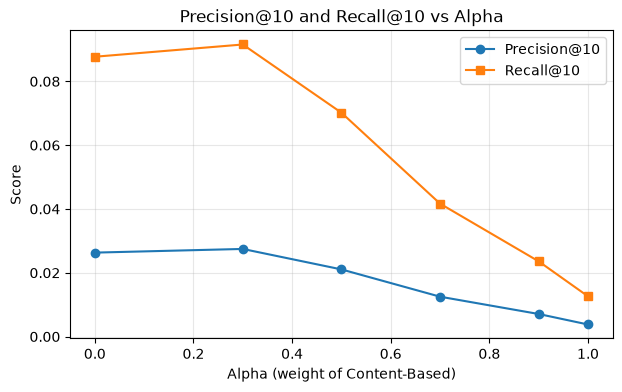

In [82]:
import matplotlib.pyplot as plt

alphas = list(results_precision.keys())
precisions = list(results_precision.values())
recalls = list(results_recall.values())

plt.figure(figsize=(7, 4))
plt.plot(alphas, precisions, marker='o', label='Precision@10')
plt.plot(alphas, recalls, marker='s', label='Recall@10')
plt.xlabel('Alpha (weight of Content-Based)')
plt.ylabel('Score')
plt.title('Precision@10 and Recall@10 vs Alpha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Interpretation: Precision@10 and Recall@10 vs Alpha 
- Just like Recall@10 on its own, Precision@10 confirms the same pattern: both metrics peak at **α = 0.3** (CF dominant) and consistently decrease as the weight of content-based increases. The fact that two different metrics agree reinforces the previous conclusion — it’s not an isolated coincidence of one metric, but a consistent signal that CF captures the individual user’s taste better than CB thematic similarity, at least in this dataset and for this top-K ranking task.
- The absolute values of the two metrics aren't directly comparable: Precision@10 always divides by the fixed list size (10), while Recall@10 divides by the number of relevant items hidden per user (3, in this split). That's why Recall@10 tends to be structurally higher than Precision@10 for the same number of hits — the difference in magnitude between the curves doesn't say anything about model quality, it just reflects the different denominators.
- As before, this doesn’t invalidate the CB component — it’s still essential for cold-start of new movies and for thematic diversity — but it confirms that, to maximize direct hits in recommendations (Precision and Recall), a lower α (giving more weight to CF) is the most defensible choice on this dataset.